In [ ]:
import numpy as np
import cupy as cp
import time
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from functools import wraps

def time_logger(func):
    """Декоратор, засекает время выполнения функции.
      Каждая функция выполняется 10 раз, после чего считается среднее время выполнения
    """
    @wraps(func)
    def wrapper(*args, **kwargs):
        avg_time = 0 # Среднее время выполнения
        k = 10 # количество выполнеий
        for i in range(k):
          start_time = time.time()  # Время начала
          result = func(*args, **kwargs)  # Запуск функции
          end_time = time.time()  # Время окончания

          execution_time = end_time - start_time
          avg_time += execution_time
        print(f"Среднее время выполнения: {avg_time/k:.6f} секунд")
        return result, avg_time
    return wrapper


In [ ]:
def addToTable(df, n_val, c_val, column):
  df[column] = [n_val, c_val]
  return df.copy()

In [ ]:
def tableGrathOut(arr_n, arr_c, arr_val):
  df_timeTable = pd.DataFrame({}, index=['numpy time (sec.)','cupy time (sec.)'])
  for index, value in enumerate(arr_val):
    df_timeTable = addToTable(df_timeTable, arr_n[index], arr_c[index], value)
  print('Таблица времени работы двух фреймворков:')
  print(df_timeTable)
  # Данные для линии X
  x = arr_val
  # Данные для линий по Y
  y1 = arr_n
  y2 = arr_c

  xlabl = 'Размерность'
  ylabl = 'Время выполнения в сек.'
  # Построение графиков
  plt.plot(x, y1, label='numpy time', color='blue', linewidth=2)
  plt.plot(x, y2, label='cupy time', color='red', linewidth=2)

  plt.title('График времени работы двух фреймворков')
  plt.xlabel(xlabl)
  plt.ylabel(ylabl)
  plt.legend()
  plt.grid(True)

  # Вывод графика
  plt.show()

  # по отдельности

  # Создание сетки: 1 строка, 2 столбца
  fig, (ax1, ax2) = plt.subplots(1, 2)

  # Первый график
  ax1.plot(x, y1, color='blue')
  ax1.set_title('numpy time')
  ax1.set_xlabel(xlabl)
  ax1.set_ylabel(ylabl)

  # Второй график
  ax2.plot(x, y2, color='red')
  ax2.set_title('cupy time')
  ax2.set_xlabel(xlabl)
  ax2.set_ylabel(ylabl)

  # Настройка расстояния между графиками
  plt.tight_layout()
  plt.show()


### Задание 1.

Поэлементные операции с большими массивами.

На вход функции подаётся массив размерностью $N$. Необходимо реализовать вычисление выражения $y = \sqrt{x}+sin(x)⋅exp(−x)$ (используйте встроенные векторные функции, обычный for не даст вам ускорения). Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 10000000].

In [ ]:
@time_logger
def calcY(x, isCp = True):
  ''' Функция для вычисления выражения y = sqrt{x}+sin(x)⋅exp(−x) '''
  if isCp:
    return cp.sqrt(xc)+cp.sin(xc)*cp.exp(-1 * xc) # вычисление в фреймворке cupy
  return np.sqrt(xn)+np.sin(xn)*np.exp(-1 * xn) # вычисление в фреймворке numpy

In [ ]:

N = 10
arr_n = []
arr_c = []
arr_val = []
for i in range(7):
  xc = cp.random.random(N).astype('f')
  xn = np.random.random(N).astype('f')
  # print(xc, xn)
  arr_val.append(N)
  print('N = ', N)
  print(' cp time: ')
  _, time_c = calcY(xc)
  print(' np time: ')
  _, time_n = calcY(xn, False)
  arr_n.append(time_n)
  arr_c.append(time_c)

  N *= 10


N =  10
 cp time: 
Среднее время выполнения: 0.000344 секунд
 np time: 
Среднее время выполнения: 0.000014 секунд
N =  100
 cp time: 
Среднее время выполнения: 0.000131 секунд
 np time: 
Среднее время выполнения: 0.000007 секунд
N =  1000
 cp time: 
Среднее время выполнения: 0.000085 секунд
 np time: 
Среднее время выполнения: 0.000012 секунд
N =  10000
 cp time: 
Среднее время выполнения: 0.000093 секунд
 np time: 
Среднее время выполнения: 0.000041 секунд
N =  100000
 cp time: 
Среднее время выполнения: 0.000079 секунд
 np time: 
Среднее время выполнения: 0.000384 секунд
N =  1000000
 cp time: 
Среднее время выполнения: 0.000085 секунд
 np time: 
Среднее время выполнения: 0.003617 секунд
N =  10000000
 cp time: 
Среднее время выполнения: 0.000102 секунд
 np time: 
Среднее время выполнения: 0.109509 секунд


Таблица времени работы двух фреймворков:
                   10        100       1000      10000     100000    1000000   \
numpy time (sec.)  0.000135  0.000065  0.000119  0.000410  0.003839  0.036171   
cupy time (sec.)   0.003442  0.001308  0.000853  0.000928  0.000790  0.000847   

                   10000000  
numpy time (sec.)  1.095088  
cupy time (sec.)   0.001023  


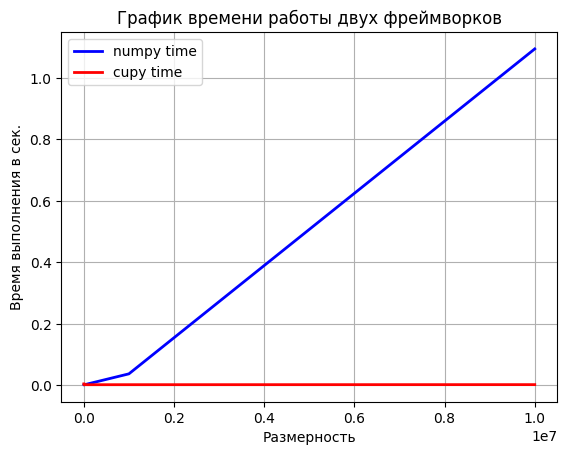

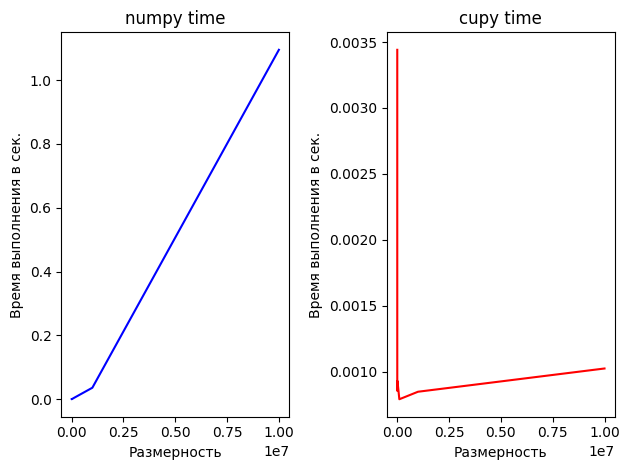

In [ ]:
tableGrathOut(arr_n, arr_c, arr_val)

### Задание 2.

Расчет статистик.

На вход функции подаётся квадртаная матрицы $A$ размерностью $N \times N$. Необходимо реализовать функцию рассчета статистик (среднее значение, медиана, мода, дисперсия, среднеквадартаичное отклонение, первый и третий квартиль) для каждой колонки матрицы. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 100000].



Метод для вычисления метрик, с вычислением Моды по столбцам

In [ ]:
def np_node(x):
  # частота уникальных значений в каждом столбце
  values, counts = np.unique(x, return_counts=True)
  # индекс максимальной частоты в каждом столбце
  index = np.argmax(counts)
  return values[index]
def cp_node(x):
  # частота уникальных значений в каждом столбце
  values, counts = cp.unique(x, return_counts=True)
  # индекс максимальной частоты в каждом столбце
  index = cp.argmax(counts)
  return values[index]
@time_logger
def calcMetrix(x, isCp = True):
  if isCp: # вычисление в фреймворке cupy
    return (
        # вычисление среднего значения по столбцам
        cp.mean(x, axis=0),
        # вычисление медианы по столбцам
        cp.median(x, axis=0),
        # вычисление моды по столбцам
        cp.apply_along_axis(cp_node, axis=0, arr=x),
        # вычисление дисперсии по столбцам
        cp.var(x, axis=0),
        # вычисление среднеквадратичного отклонения по столбцам
        cp.std(x, axis=0),
        # вычисление первого квартиля
        cp.quantile(x, 0.25, axis=0),
        # вычисление третьего квартиля
        cp.quantile(x, 0.75, axis=0),
    )
  return (
      # вычисление среднего значения по столбцам
      np.mean(x, axis=0),
      # вычисление медианы по столбцам
      np.median(x, axis=0),
      # вычисление моды по столбцам
      np.apply_along_axis(np_node, axis=0, arr=x),
      # вычисление дисперсии по столбцам
      np.var(x, axis=0),
      # вычисление среднеквадратичного отклонения по столбцам
      np.std(x, axis=0),
      # вычисление первого квартиля
      np.quantile(x, 0.25, axis=0),
      # вычисление третьего квартиля
      np.quantile(x, 0.75, axis=0),
  )

Метод для вычисления метрик, без вычисления Моды по столбцам

In [ ]:
@time_logger
def calcMetrixWithoutMod(x, isCp = True):
  if isCp: # вычисление в фреймворке cupy
    return (
        # вычисление среднего значения по столбцам
        cp.mean(x, axis=0),
        # вычисление медианы по столбцам
        cp.median(x, axis=0),
        # вычисление моды по столбцам
        # cp.apply_along_axis(cp_node, axis=0, arr=x),
        # вычисление дисперсии по столбцам
        cp.var(x, axis=0),
        # вычисление среднеквадратичного отклонения по столбцам
        cp.std(x, axis=0),
        # вычисление первого квартиля
        cp.quantile(x, 0.25, axis=0),
        # вычисление третьего квартиля
        cp.quantile(x, 0.75, axis=0),
    )
  return (
      # вычисление среднего значения по столбцам
      np.mean(x, axis=0),
      # вычисление медианы по столбцам
      np.median(x, axis=0),
      # вычисление моды по столбцам
      # np.apply_along_axis(np_node, axis=0, arr=x),
      # вычисление дисперсии по столбцам
      np.var(x, axis=0),
      # вычисление среднеквадратичного отклонения по столбцам
      np.std(x, axis=0),
      # вычисление первого квартиля
      np.quantile(x, 0.25, axis=0),
      # вычисление третьего квартиля
      np.quantile(x, 0.75, axis=0),
  )

Результаты вычислений без вычисления Моды:

In [ ]:
# Без apply_along_axis
N = 500
arr_n = []
arr_c = []
arr_val = []
for i in range(20):
  xc = cp.random.rand(N, N).astype('f')
  xn = np.random.rand(N, N).astype('f')
  # print(xc, xn)
  arr_val.append(N)
  print('N = ', N)
  print('cp time: ')
  _, time_c = calcMetrixWithoutMod(xc)
  print('np time: ')
  _, time_n = calcMetrixWithoutMod(xn, False)
  arr_n.append(time_n)
  arr_c.append(time_c)

  N += 500


N =  500
cp time: 
Среднее время выполнения: 0.001293 секунд
np time: 
Среднее время выполнения: 0.012857 секунд
N =  1000
cp time: 
Среднее время выполнения: 0.001112 секунд
np time: 
Среднее время выполнения: 0.056207 секунд
N =  1500
cp time: 
Среднее время выполнения: 0.001292 секунд
np time: 
Среднее время выполнения: 0.133903 секунд
N =  2000
cp time: 
Среднее время выполнения: 0.001677 секунд
np time: 
Среднее время выполнения: 0.244700 секунд
N =  2500
cp time: 
Среднее время выполнения: 0.032241 секунд
np time: 
Среднее время выполнения: 0.321216 секунд
N =  3000
cp time: 
Среднее время выполнения: 0.057343 секунд
np time: 
Среднее время выполнения: 0.570056 секунд
N =  3500
cp time: 
Среднее время выполнения: 0.077258 секунд
np time: 
Среднее время выполнения: 0.776820 секунд
N =  4000
cp time: 
Среднее время выполнения: 0.111403 секунд
np time: 
Среднее время выполнения: 1.124940 секунд
N =  4500
cp time: 
Среднее время выполнения: 0.151101 секунд
np time: 
Среднее время вып

Таблица времени работы двух фреймворков:
                      500       1000      1500      2000      2500      3000   \
numpy time (sec.)  0.128575  0.562070  1.339032  2.447002  3.212157  5.700561   
cupy time (sec.)   0.012928  0.011117  0.012920  0.016766  0.322407  0.573426   

                      3500       4000       4500       5000       5500   \
numpy time (sec.)  7.768201  11.249405  12.624273  15.951341  17.084802   
cupy time (sec.)   0.772576   1.114025   1.511011   1.890251   2.406551   

                       6000       6500       7000       7500       8000   \
numpy time (sec.)  20.076774  23.732496  27.896778  36.083536  53.253582   
cupy time (sec.)    2.956602   3.545550   4.137264   4.808138   5.575326   

                       8500       9000       9500       10000  
numpy time (sec.)  46.049105  48.288933  52.304765  56.773059  
cupy time (sec.)    6.355288   7.257824   8.198137   9.177471  


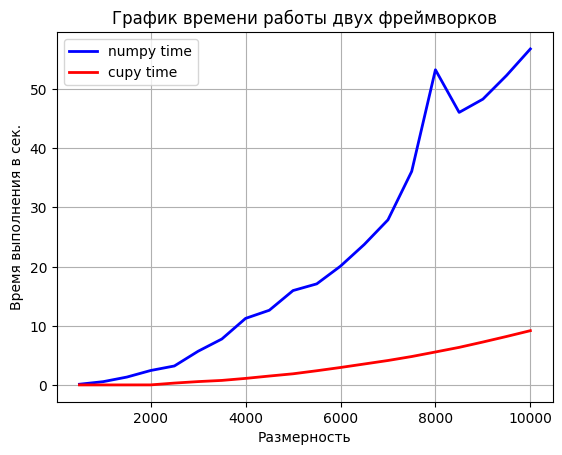

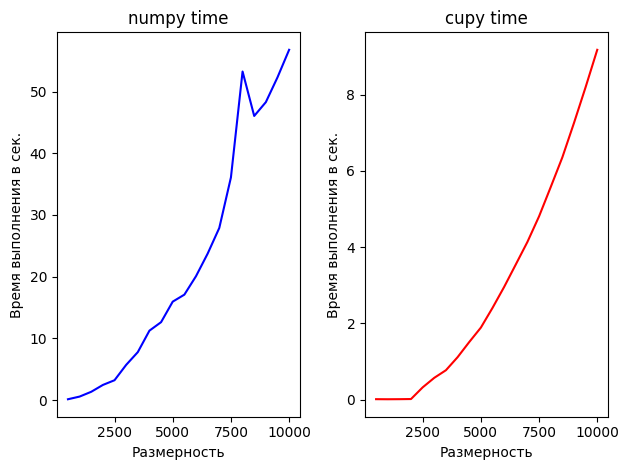

In [ ]:
tableGrathOut(arr_n, arr_c, arr_val)

Результаты вычислений с вычислением Моды:

In [ ]:

N = 500
arr_n = []
arr_c = []
arr_val = []
for i in range(20):
  xc = cp.random.rand(N, N).astype('f')
  xn = np.random.rand(N, N).astype('f')
  # print(xc, xn)
  arr_val.append(N)

  print('cp time: ')
  _, time_c = calcMetrix(xc)
  print('np time: ')
  _, time_n = calcMetrix(xn, False)
  arr_n.append(time_n)
  arr_c.append(time_c)

  N += 500


cp time: 
Среднее время выполнения: 0.418139 секунд
np time: 
Среднее время выполнения: 0.026064 секунд
cp time: 
Среднее время выполнения: 0.860172 секунд
np time: 
Среднее время выполнения: 0.114860 секунд
cp time: 
Среднее время выполнения: 1.279604 секунд
np time: 
Среднее время выполнения: 0.162584 секунд
cp time: 
Среднее время выполнения: 1.690962 секунд
np time: 
Среднее время выполнения: 0.283646 секунд
cp time: 
Среднее время выполнения: 2.137617 секунд
np time: 
Среднее время выполнения: 0.484623 секунд
cp time: 
Среднее время выполнения: 2.583842 секунд
np time: 
Среднее время выполнения: 0.625167 секунд
cp time: 
Среднее время выполнения: 3.079670 секунд
np time: 
Среднее время выполнения: 0.893226 секунд
cp time: 
Среднее время выполнения: 3.466118 секунд
np time: 
Среднее время выполнения: 1.132407 секунд
cp time: 
Среднее время выполнения: 3.959967 секунд
np time: 
Среднее время выполнения: 1.399730 секунд
cp time: 
Среднее время выполнения: 4.754634 секунд
np time: 
Ср

Таблица времени работы двух фреймворков:
                      500       1000       1500       2000       2500   \
numpy time (sec.)  0.260642  1.148601   1.625842   2.836462   4.846226   
cupy time (sec.)   4.181388  8.601720  12.796041  16.909616  21.376168   

                       3000       3500       4000       4500       5000   \
numpy time (sec.)   6.251667   8.932265  11.324069  13.997296  17.028001   
cupy time (sec.)   25.838418  30.796701  34.661179  39.599670  47.546342   

                       5500       6000       6500       7000       7500   \
numpy time (sec.)  20.827729  24.327909  29.155655  33.569101  43.519986   
cupy time (sec.)   52.952861  57.638855  63.940848  67.989983  77.603527   

                       8000       8500       9000       9500       10000  
numpy time (sec.)  60.367689  50.588173  55.566846  63.015523  69.892951  
cupy time (sec.)   85.790779  91.745869  88.571117  93.972205  99.687344  


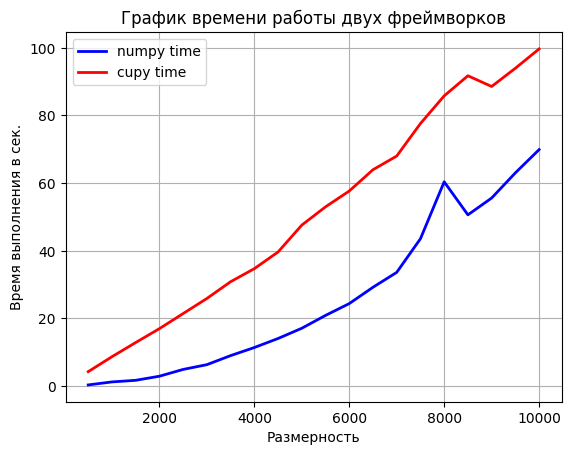

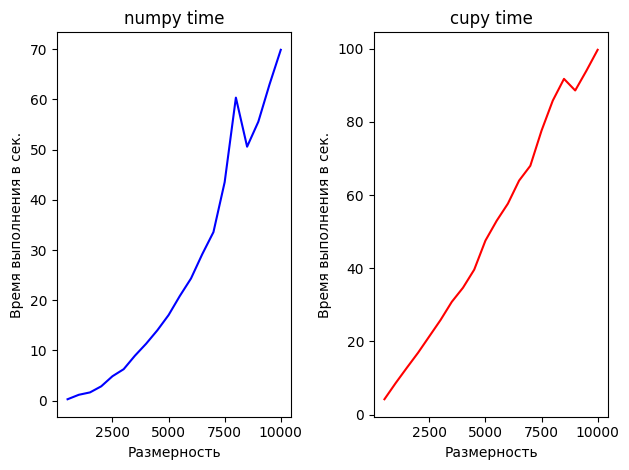

In [ ]:
tableGrathOut(arr_n, arr_c, arr_val)

**Анализ результатов**


По результатам вычислений второго задания, можно заметить, что формула для рассчета моды  по столбцам не оптимизируется со средствами cupy из-за чего время выполнения увеличивается быстрее чем через numpy методы. Если вычислять метрики без моды, cupy работает быстрее

### Задание 3.

Матричное умножение.

На вход функции подаётся две квадртаная матрицы $A$ и $B$ размерностью $N \times N$. Необходимо реализовать вычисление их произведения $C = A \cdot B$. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 4096].



In [ ]:
@time_logger
def calcDot(x, y, isCp = True):
  ''' Функция для вычисления произведение двух матриц '''
  if isCp:
    return cp.dot(x,y) # вычисление в фреймворке cupy
  return np.dot(x,y) # вычисление в фреймворке numpy

In [ ]:
N = 2
arr_n = []
arr_c = []
arr_val = []
for i in range(12):
  xc1 = cp.random.rand(N, N).astype('f')
  xn1 = np.random.rand(N, N).astype('f')
  xc2 = cp.random.rand(N, N).astype('f')
  xn2 = np.random.rand(N, N).astype('f')
  # print(xc, xn)
  arr_val.append(N)
  print('N = ', N)
  print('cp time: ')
  _, time_c = calcDot(xc1, xc2)
  print('np time: ')
  _, time_n = calcDot(xn1, xn2, False)
  arr_n.append(time_n)
  arr_c.append(time_c)

  N *= 2


N =  2
cp time: 
Среднее время выполнения: 0.014710 секунд
np time: 
Среднее время выполнения: 0.000128 секунд
N =  4
cp time: 
Среднее время выполнения: 0.000037 секунд
np time: 
Среднее время выполнения: 0.000002 секунд
N =  8
cp time: 
Среднее время выполнения: 0.000029 секунд
np time: 
Среднее время выполнения: 0.000002 секунд
N =  16
cp time: 
Среднее время выполнения: 0.000035 секунд
np time: 
Среднее время выполнения: 0.000002 секунд
N =  32
cp time: 
Среднее время выполнения: 0.001173 секунд
np time: 
Среднее время выполнения: 0.000006 секунд
N =  64
cp time: 
Среднее время выполнения: 0.000044 секунд
np time: 
Среднее время выполнения: 0.000015 секунд
N =  128
cp time: 
Среднее время выполнения: 0.000548 секунд
np time: 
Среднее время выполнения: 0.000240 секунд
N =  256
cp time: 
Среднее время выполнения: 0.004533 секунд
np time: 
Среднее время выполнения: 0.000429 секунд
N =  512
cp time: 
Среднее время выполнения: 0.000068 секунд
np time: 
Среднее время выполнения: 0.002873

Таблица времени работы двух фреймворков:
                       2         4         8         16        32        64    \
numpy time (sec.)  0.001278  0.000018  0.000017  0.000023  0.000056  0.000146   
cupy time (sec.)   0.147103  0.000367  0.000289  0.000348  0.011733  0.000440   

                       128       256       512       1024      2048       4096  
numpy time (sec.)  0.002395  0.004289  0.028733  0.191771  1.553728  13.084994  
cupy time (sec.)   0.005484  0.045335  0.000677  0.000722  0.000885   0.000865  


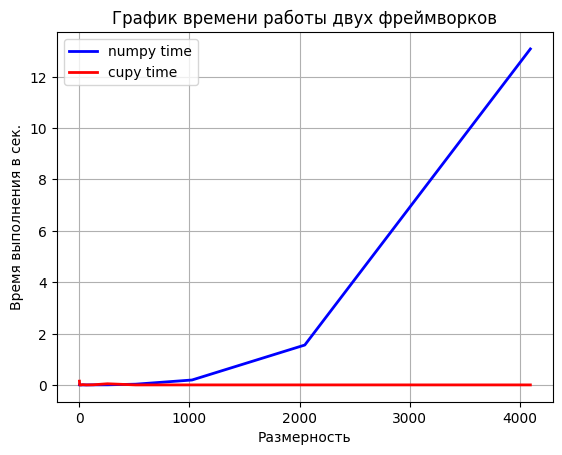

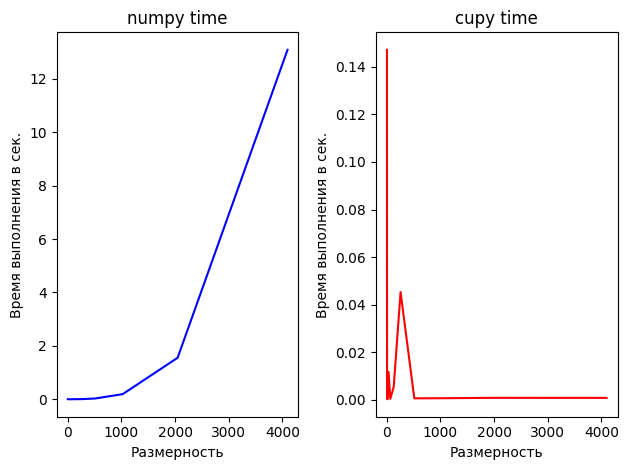

In [ ]:
tableGrathOut(arr_n, arr_c, arr_val)

### Задание 4.

Ряд Маклорена.

На вход подается массив размерностью $N$ со значениями [-10, 10] и число $M$ - количество многочленов для апрокимации. Необходимо реализовать функцию, которая вычисляет разложение функции $sin(x)$ в ряд Маклорена для заданного массива и количество многочленов для апрокимации. Для экспериментов ограничим значение, которое может принимать $N$ в задачах следующим интервалом [1, 10000000], а $M$ - одним, любым значением, но не меньше 5.


In [ ]:
import math

In [ ]:
@time_logger
def getMacloren(x, n_terms, isCp = True):
  ''' Функция для раздложения в ряд Маклорена '''
  if isCp:
    sin_x = cp.zeros_like(x, dtype=float)
    for n in range(n_terms):
        term = ((-1)**n * cp.power(x,(2*n + 1))) / math.factorial(2*n + 1)
        sin_x += term
    return sin_x
  sin_x = np.zeros_like(x, dtype=float)
  for n in range(n_terms):
      term = ((-1)**n * np.power(x,(2*n + 1))) / math.factorial(2*n + 1)
      sin_x += term
  return sin_x

In [ ]:
N = 10
M = 5
min_val = -10.0
max_val = 10.0

arr_n = []
arr_c = []
arr_val = []
for i in range(7):
  xc = (max_val - min_val) * cp.random.rand(5) + min_val
  xn = (max_val - min_val) * np.random.rand(5) + min_val
  # print(xc, xn)
  arr_val.append(N)
  print('N = ', N)
  print('cp time: ')
  _, time_c = getMacloren(xc1, M)
  print('np time: ')
  _, time_n = getMacloren(xn1, M, False)
  arr_n.append(time_n)
  arr_c.append(time_c)

  N *= 10


N =  10
cp time: 
Среднее время выполнения: 0.034049 секунд
np time: 
Среднее время выполнения: 0.627017 секунд
N =  100
cp time: 
Среднее время выполнения: 0.000614 секунд
np time: 
Среднее время выполнения: 0.589962 секунд
N =  1000
cp time: 
Среднее время выполнения: 0.000438 секунд
np time: 
Среднее время выполнения: 0.624139 секунд
N =  10000
cp time: 
Среднее время выполнения: 0.000429 секунд
np time: 
Среднее время выполнения: 0.592366 секунд
N =  100000
cp time: 
Среднее время выполнения: 0.000891 секунд
np time: 
Среднее время выполнения: 0.618369 секунд
N =  1000000
cp time: 
Среднее время выполнения: 0.000433 секунд
np time: 
Среднее время выполнения: 0.588044 секунд
N =  10000000
cp time: 
Среднее время выполнения: 0.000463 секунд
np time: 
Среднее время выполнения: 0.622423 секунд


Таблица времени работы двух фреймворков:
                   10        100       1000      10000     100000    1000000   \
numpy time (sec.)  6.270171  5.899617  6.241389  5.923661  6.183686  5.880442   
cupy time (sec.)   0.340489  0.006138  0.004378  0.004287  0.008907  0.004331   

                   10000000  
numpy time (sec.)  6.224230  
cupy time (sec.)   0.004631  


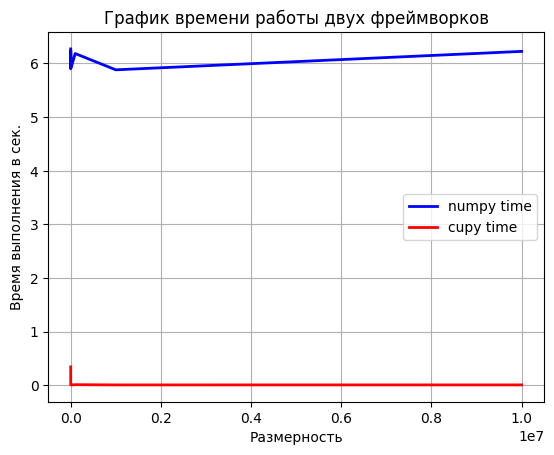

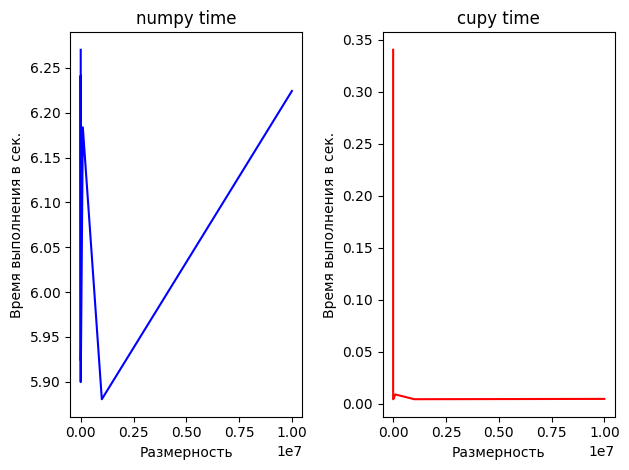

In [ ]:
tableGrathOut(arr_n, arr_c, arr_val)

**Анализ результатов Первой части**

Cupy методы работают быстрее numpy методов, на массивах с большой размерностью.

Например на массивах размерностью 10 (как в первом задании, cupy отрабатывает в 30 раз дольше)


## Часть 2.


### Задание.

Реализовать небольшую свёрточную нейронную сеть для задачи бинарной классификации, которая может проводит вычисления и обучаться как на cpu (с использованием numpy), так и на gpu (с использованием numba).

![Пример простейшей нейронной сети](images/convolution-01.jpg.webp)